<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_2_ROC_AUC_Threshold_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Predicting Credit Default: Part 3
## ROC Curves and Threshold Tuning

Author: Brad Sheese

---

## Introduction: Comparing Curves, Not Points

In Part 2, we learned that changing the decision threshold (the point where we say "yes" vs. "no") drastically changes our precision and recall. This creates a problem: if I have two models, how do I know which one is better overall if their performance depends on an arbitrary threshold choice?

In this notebook, we introduce the ROC (Receiver Operating Characteristic) curve and the AUC (Area Under the Curve) score. These tools allow us to evaluate a model's quality across *every* possible threshold simultaneously. We will also learn how to use Youden's J statistic to find the mathematically "optimal" threshold, and how to pick a threshold based on real business costs.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Interpret ROC curves and understand the trade-off between TPR and FPR.
2. Use AUC to compare the performance of different models.
3. Understand why precision-recall curves are sometimes better than ROC curves for imbalanced data.
4. Calculate Youden's J to find the "goldilocks" decision boundary.
5. Pick a threshold based on real business costs, not just mathematical optimality.

## Section 1: Setup and Data Loading

As before, we'll train our balanced XGBoost model on the South German Credit data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, recall_score, precision_score

data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame
y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])
X_encoded = pd.get_dummies(X, drop_first=True)

# Clean column names for XGBoost compatibility
import re
X_encoded.columns = [re.sub(r"[<>[\]]", "_", col) for col in X_encoded.columns]

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
print("Model ready for evaluation.")


Model ready for evaluation.


## Section 2: The ROC Curve (TPR vs. FPR)

The ROC curve plots two metrics against each other as we slide our threshold from 0 to 1:

1.  True Positive Rate (TPR): Same as recall. "Of all defaults, how many did we catch?"
2.  False Positive Rate (FPR): "Of all good customers, how many did we wrongly flag?" (Note: FPR = 1 - Specificity).

### What to Look For:
- A perfect model would hug the top-left corner (TPR=1, FPR=0): catch all defaulters, flag zero good customers.
- A random model would be a diagonal line (the chance line): no better than flipping a coin.
- The more "arched" the curve is toward the top-left, the better the model is at separating the two classes.

### What AUC Actually Means

The AUC (Area Under the Curve) is the single best metric for model comparison. It represents the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

Concrete example: If you randomly pick one defaulter and one good customer from the test set, an AUC of 0.80 means the model will correctly assign a higher default probability to the defaulter 80% of the time. An AUC of 0.50 means the model is no better than a coin flip.

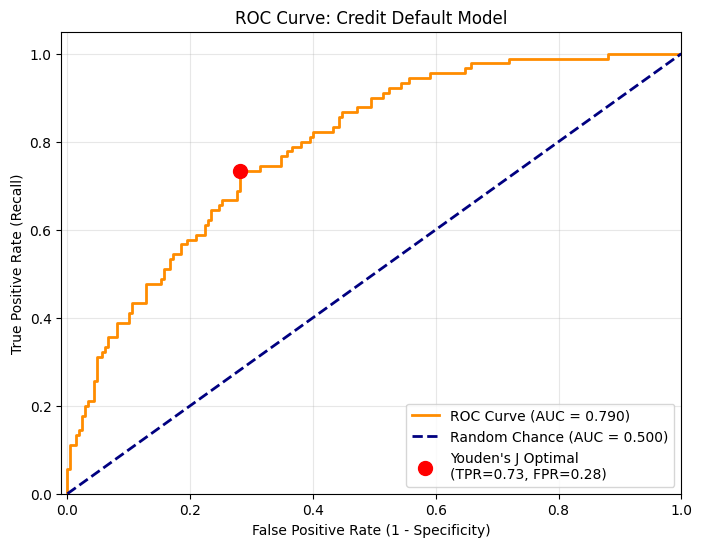

AUC = 0.790

Interpretation: If you randomly pick one defaulter and one good customer,
the model correctly ranks the defaulter as higher-risk 79.0% of the time.


In [2]:
# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Find Youden's J optimal point for annotation
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.500)')

# Mark the Youden's J optimal point
plt.scatter([best_fpr], [best_tpr], color='red', s=100, zorder=5, label=f"Youden's J Optimal\n(TPR={best_tpr:.2f}, FPR={best_fpr:.2f})")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Credit Default Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC = {roc_auc:.3f}")
print(f"\nInterpretation: If you randomly pick one defaulter and one good customer,")
print(f"the model correctly ranks the defaulter as higher-risk {roc_auc*100:.1f}% of the time.")

### Reading the Curve

The red dot marks the Youden's J optimal point — the threshold that maximizes TPR while minimizing FPR. Look at where it sits:

- At the far left (low FPR): The model is very conservative. It catches few defaulters but barely flags any good customers.
- At the top (high TPR): The model catches almost all defaulters but also flags many good customers.
- The "knee" of the curve is where you get the most TPR for the least FPR — this is typically close to the Youden's J point.

An AUC of 0.790 means the model is acceptable at distinguishing defaulters from good customers.

## Section 3: ROC vs. Precision-Recall Curves

While ROC curves are standard, they can be over-optimistic on imbalanced data. Here's why:

The FPR denominator is all actual negatives (good customers). If you have hundreds of good customers, your FPR stays low even if you have dozens of false positives. The ROC curve looks great because the true negatives overwhelm the false positives in the denominator.

The precision-recall (PR) curve is more "honest" for imbalanced data because it ignores true negatives entirely. Precision only asks: "of the people we flagged, how many were actually bad?" If you flag many good customers, precision drops — regardless of how many true negatives you have.

Let's compare.

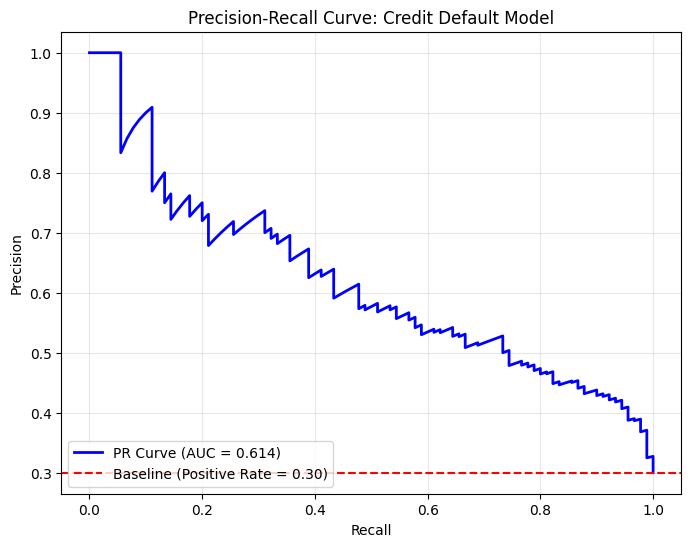

PR AUC = 0.614
Baseline (random guessing precision) = 0.300


In [3]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)  # Note: order is (x, y)
pos_rate = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.axhline(y=pos_rate, color='red', linestyle='--', label=f'Baseline (Positive Rate = {pos_rate:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Credit Default Model')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f"PR AUC = {pr_auc:.3f}")
print(f"Baseline (random guessing precision) = {pos_rate:.3f}")

### Reading the PR Curve

The red dashed line shows the baseline precision you'd get from random guessing: if ~30% of applicants are defaulters, a random classifier has ~30% precision. Any useful model must stay well above that line.

Notice how the PR curve behaves at the extremes:
- At high recall (right side): The model catches most defaulters, but precision drops — many false alarms dilute the positive predictions.
- At high precision (left side): When the model is very selective, precision is high but recall is low — it only flags the most obvious defaulters.

If the PR curve hugs close to the baseline, your model isn't doing much better than random guessing for the minority class — even if the ROC curve looks impressive.

## Section 4: Finding the "Goldilocks" Threshold (Youden's J)

Now that we've evaluated the *curve*, how do we pick a single *point* (threshold) to use in production?

One common method is Youden's J statistic. It finds the threshold that maximizes the distance between the ROC curve and the random chance line:

$$J = TPR - FPR$$

This finds the threshold that gives you the most "bang for your buck" — maximizing detections while minimizing false alarms. It treats both types of error as equally costly, which is a useful starting point but rarely reflects real-world business priorities.

In [4]:
# Calculate J for all thresholds on the ROC curve
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- Youden's J Results ---")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max J-Score:    {j_scores[best_idx]:.3f}")
print(f"TPR (Recall) at this point: {tpr[best_idx]:.3f}")
print(f"FPR at this point: {fpr[best_idx]:.3f}")

# Compare to default 0.5
y_default = (y_proba >= 0.5).astype(int)
from sklearn.metrics import recall_score, precision_score
default_tpr = recall_score(y_test, y_default)
default_fpr = ((y_default == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
print(f"\n--- For Comparison: Default Threshold (0.5) ---")
print(f"TPR (Recall): {default_tpr:.3f}")
print(f"FPR:          {default_fpr:.3f}")

--- Youden's J Results ---
Best Threshold: 0.393
Max J-Score:    0.452
TPR (Recall) at this point: 0.733
FPR at this point: 0.281

--- For Comparison: Default Threshold (0.5) ---
TPR (Recall): 0.589
FPR:          0.210


## Section 5: Business Cost Sensitivity

While Youden's J is mathematically optimal, it assumes that a false positive and a false negative have equal cost. In the real world, they rarely do.

Assume:
- A false positive (wrongly denying a loan) costs the bank $500 in lost interest.
- A false negative (wrongly approving a bad loan) costs the bank $5,000 in lost principal.

In this case, we would want to move our threshold to be much more sensitive to catch those defaults, even if it means more false alarms.

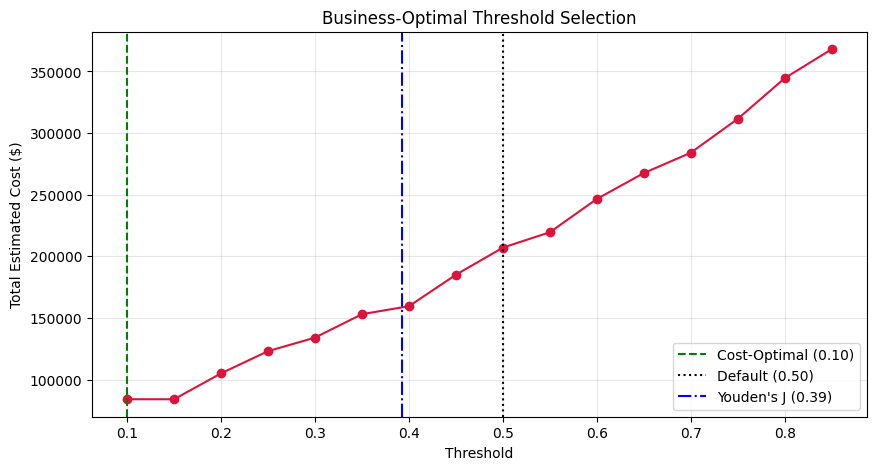

--- Cost Comparison ---
Default threshold (0.50):  $207,000
Youden's J (0.39):       $149,500
Cost-optimal (0.10):  $84,000

Savings vs. default:       $123,000


In [5]:
test_thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in test_thresholds:
    y_t = (y_proba >= t).astype(int)
    fp = ((y_t == 1) & (y_test == 0)).sum()
    fn = ((y_t == 0) & (y_test == 1)).sum()
    total_cost = (fp * 500) + (fn * 5000)
    costs.append(total_cost)

cost_optimal_idx = np.argmin(costs)
cost_optimal_threshold = test_thresholds[cost_optimal_idx]
min_cost = costs[cost_optimal_idx]

# Calculate cost at default 0.5
y_default = (y_proba >= 0.5).astype(int)
fp_default = ((y_default == 1) & (y_test == 0)).sum()
fn_default = ((y_default == 0) & (y_test == 1)).sum()
cost_default = (fp_default * 500) + (fn_default * 5000)

# Calculate cost at Youden's J threshold
y_youden = (y_proba >= best_threshold).astype(int)
fp_youden = ((y_youden == 1) & (y_test == 0)).sum()
fn_youden = ((y_youden == 0) & (y_test == 1)).sum()
cost_youden = (fp_youden * 500) + (fn_youden * 5000)

plt.figure(figsize=(10, 5))
plt.plot(test_thresholds, costs, marker='o', color='crimson')
plt.axvline(x=cost_optimal_threshold, color='green', linestyle='--', label=f'Cost-Optimal ({cost_optimal_threshold:.2f})')
plt.axvline(x=0.5, color='black', linestyle=':', label=f'Default (0.50)')
plt.axvline(x=best_threshold, color='blue', linestyle='-.', label=f"Youden's J ({best_threshold:.2f})")
plt.xlabel('Threshold')
plt.ylabel('Total Estimated Cost ($)')
plt.title('Business-Optimal Threshold Selection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"--- Cost Comparison ---")
print(f"Default threshold (0.50):  ${cost_default:,.0f}")
print(f"Youden's J ({best_threshold:.2f}):       ${cost_youden:,.0f}")
print(f"Cost-optimal ({cost_optimal_threshold:.2f}):  ${min_cost:,.0f}")
print(f"\nSavings vs. default:       ${cost_default - min_cost:,.0f}")

### Interpreting the Cost Curve

The cost curve shows the total estimated dollar cost at each threshold. The minimum point is the threshold that saves the bank the most money.

Notice how the cost-optimal threshold differs from both the default 0.5 and Youden's J. This is because the cost curve directly encodes your business priorities: false negatives are 10x more expensive than false positives, so the optimal threshold shifts lower to catch more defaulters, even at the cost of more false alarms.

Key takeaway: Youden's J gives you a mathematically sound starting point, but the *right* threshold depends on your specific cost structure. Always ask: "What does a false positive cost us? What does a false negative cost us?" Then pick the threshold that minimizes total cost.

## Conclusion

We have now mastered the art of classification evaluation! Key takeaways:

1. AUC tells you the model's ranking ability — the probability it correctly ranks a random defaulter above a random good customer. It's threshold-independent, making it ideal for comparing models.
2. PR curves are more honest for imbalanced data — they ignore true negatives and focus on how well the model handles the minority class.
3. Youden's J finds the mathematically optimal threshold — the point that maximizes TPR while minimizing FPR.
4. Business costs should drive the final threshold choice — the mathematically optimal threshold rarely matches the business-optimal one. Always model your real costs.

In Part 4, we will look at how to compare multiple model types (Decision Trees, SVMs, etc.) and how to extend these concepts to multiclass problems.